# Netflix Movies and TV Shows Analysis

**Tools:** Python, Pandas, Matplotlib, Seaborn. This notebook studies catalog composition and additions in the supplied Kaggle snapshot. It does not measure viewing or popularity.

## 1. Load and understand the data

Inspect the original CSV before changing it. Null counts help distinguish missing metadata from actual zero values.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from clean_data import clean_data
RAW = ROOT / "data" / "raw" / "netflix_titles.csv"
raw = pd.read_csv(RAW)
print("Shape:", raw.shape)
display(raw.dtypes.to_frame("dtype"))
display(raw.head())
display(raw.describe(include="all").T)
display(raw.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("Exact duplicate rows:", raw.duplicated().sum())

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Victus\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


D:\netflix-content-analysis-python\src\clean_data.py:48: SyntaxWarning: invalid escape sequence '\s'
  exploded = df.assign(**{column: df[column].fillna("Unknown").str.split(",\s*")}).explode(column)


Shape: (8807, 12)


,dtype
show_id,str
type,str
title,str
director,str
cast,str
country,str
date_added,str
release_year,int64
rating,str
duration,str


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


Exact duplicate rows: 0


### Initial observations

This table has one row per Netflix title and mixes Movies with TV Shows. Some columns hold comma-separated values, so a title can belong to multiple countries, genres, directors, or cast members. Missing director/cast/country values mean metadata is unavailable, not that a title should be discarded. `date_added`, `rating`, and `duration` can be missing or inconsistently populated. The analysis treats this as a catalog snapshot, not a viewing dataset.

## 2. Clean the data

The reusable steps live in `src/clean_data.py`. Text is trimmed before duplicate detection. Director, cast, and country missing values become `Unknown` to retain titles. Dates and durations are parsed with invalid values left missing. Rows with a duration in the rating field are repaired when detectable. Exploded tables put one country, genre, actor, or director on each row; they are useful for dimension counts, while title counts should use distinct `show_id`. Rating groups follow common US guidance labels and unsupported/unknown codes remain `Not Rated`.

In [2]:
sns.set_theme(style="whitegrid", palette=["#E50914", "#333333", "#777777"])
df, cleaning_summary = clean_data()
print(f"Rows: {cleaning_summary['rows_before']:,} -> {cleaning_summary['rows_after']:,}")
print("Duplicates removed:", cleaning_summary["duplicates_removed"])
print("Rows repaired from rating field:", cleaning_summary["misplaced_rating_rows"])
display(pd.DataFrame({"before": pd.Series(cleaning_summary["nulls_before"]), "after": pd.Series(cleaning_summary["nulls_after"])}).fillna(0).astype(int))
cleaned_dir = ROOT / "data" / "cleaned"
by_country = pd.read_csv(cleaned_dir / "netflix_by_country.csv")
by_genre = pd.read_csv(cleaned_dir / "netflix_by_genre.csv")
by_cast = pd.read_csv(cleaned_dir / "netflix_by_cast.csv")
by_director = pd.read_csv(cleaned_dir / "netflix_by_director.csv")

Rows: 8,807 -> 8,807
Duplicates removed: 0
Rows repaired from rating field: 3


,before,after
cast,825,0
content_age,0,10
country,831,0
date_added,10,10
description,0,0
director,2634,0
duration,3,0
duration_unit,0,0
duration_value,0,0
listed_in,0,0


## 3. Exploratory analysis

Each chart is saved under `images/`. Counts use unique title IDs where a title can appear more than once in an exploded table.

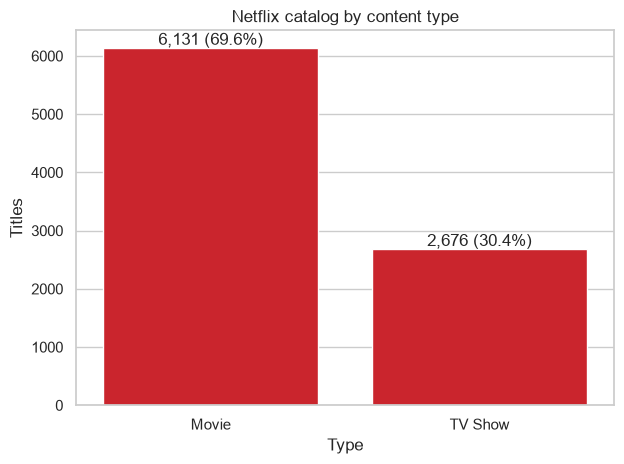

Type totals and share (%):
          count  percent
type                   
Movie     6131     69.6
TV Show   2676     30.4


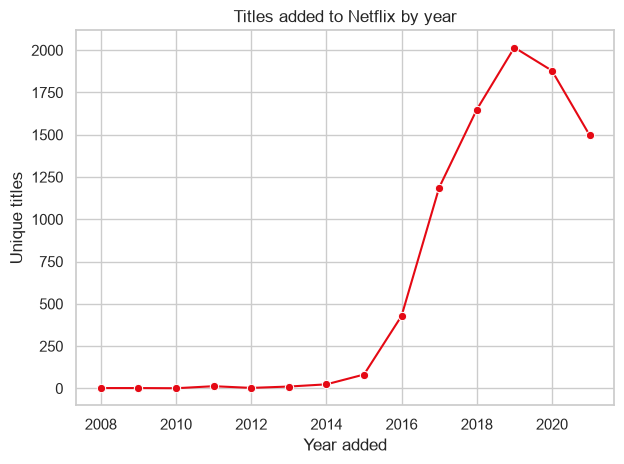

Peak addition year: 2019 with 2016 titles


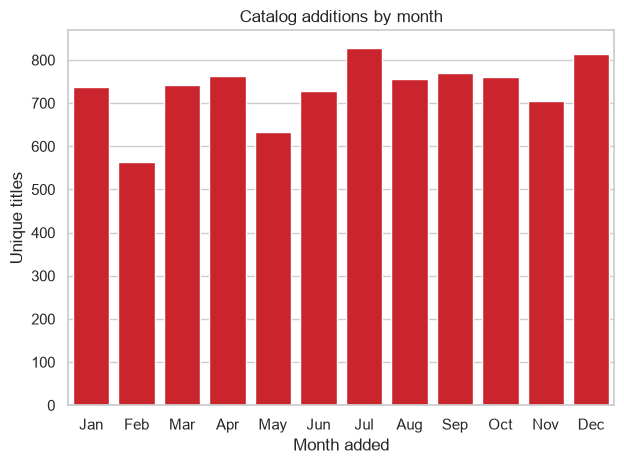

Most common month: July 827


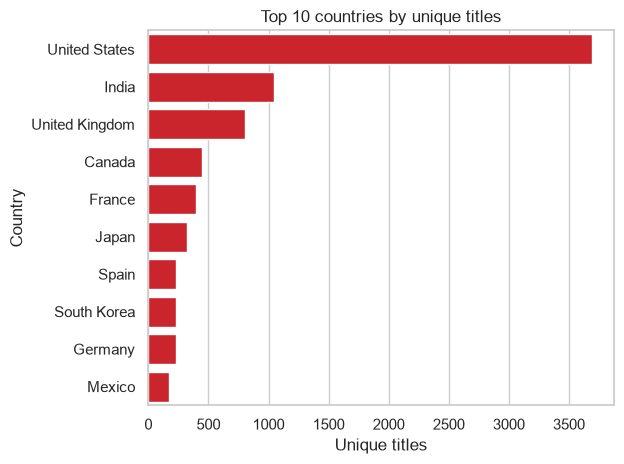

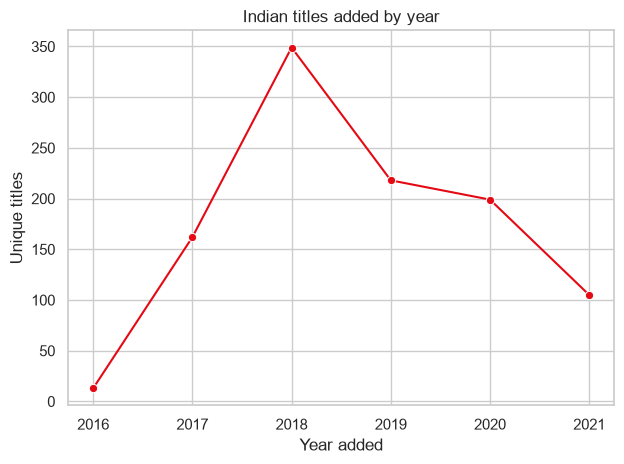

Top countries:
 country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: show_id, dtype: int64


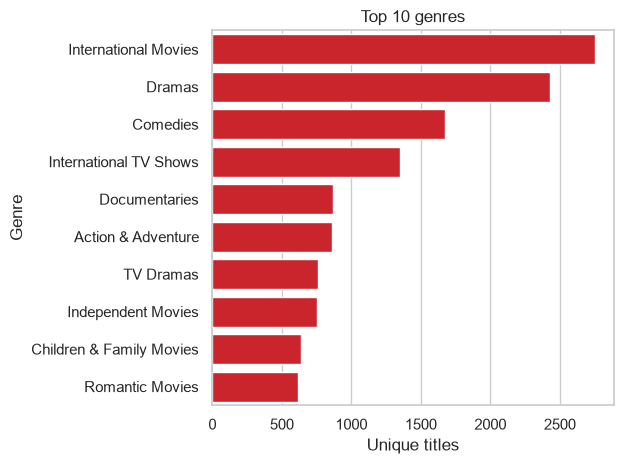

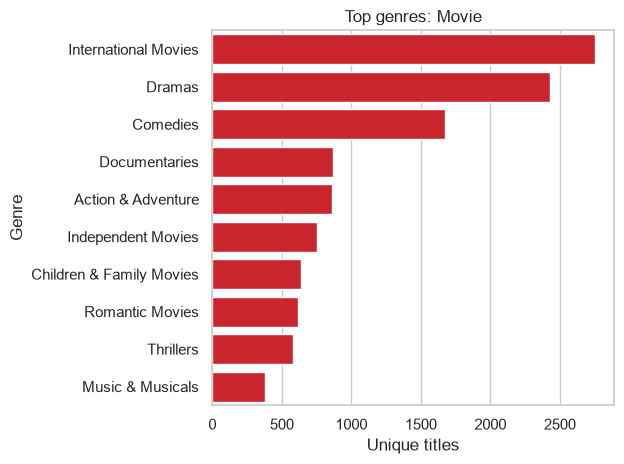

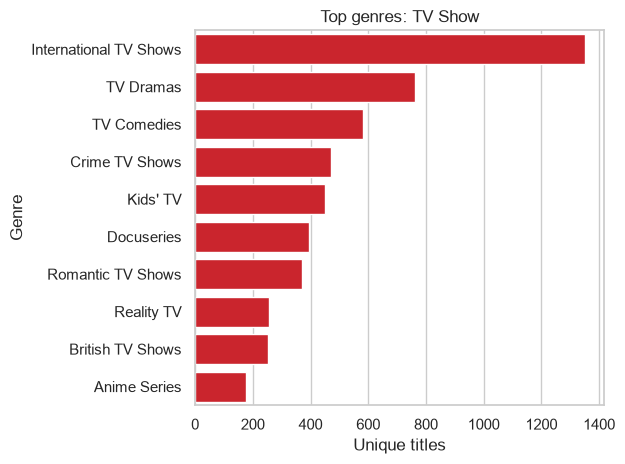

Top genres:
 listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: show_id, dtype: int64


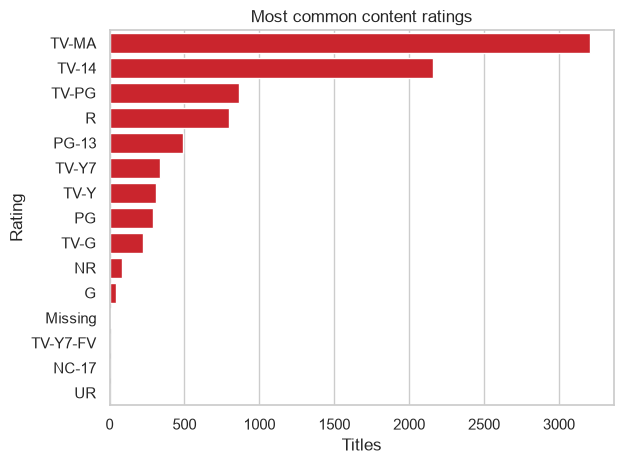

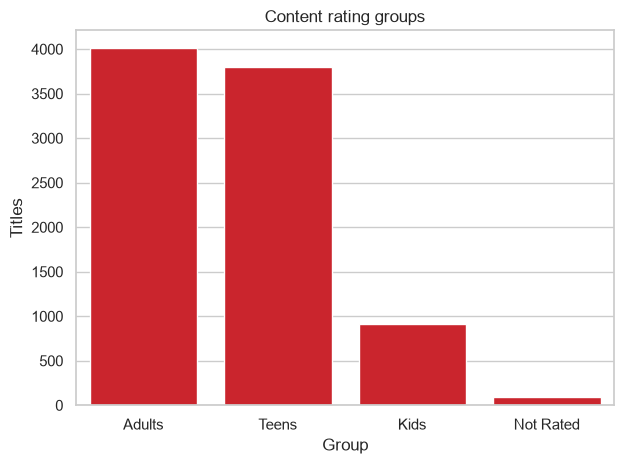

Adult-oriented titles: 45.5%


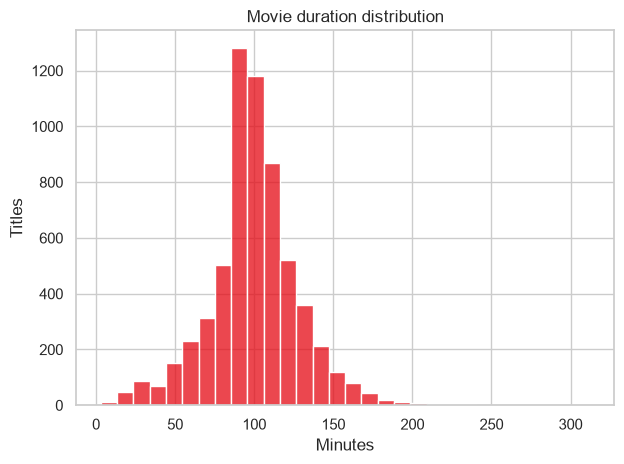

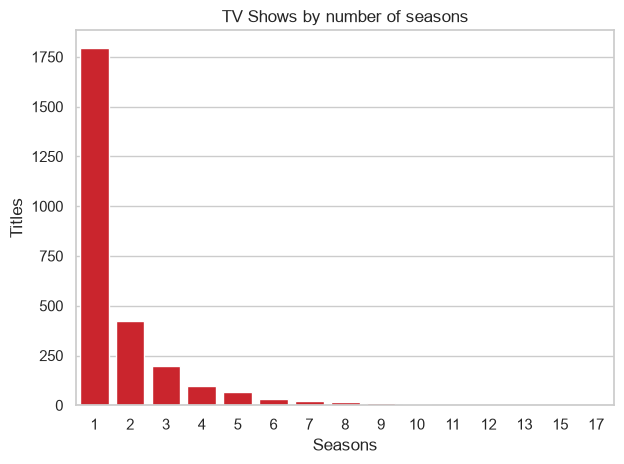

Movie duration: mean 99.6 min; median 98.0 min
TV show season distribution:
 seasons
1     1793
2      425
3      199
4       95
5       65
6       33
7       23
8       17
9        9
10       7
11       2
12       2
13       3
15       2
17       1
Name: count, dtype: int64


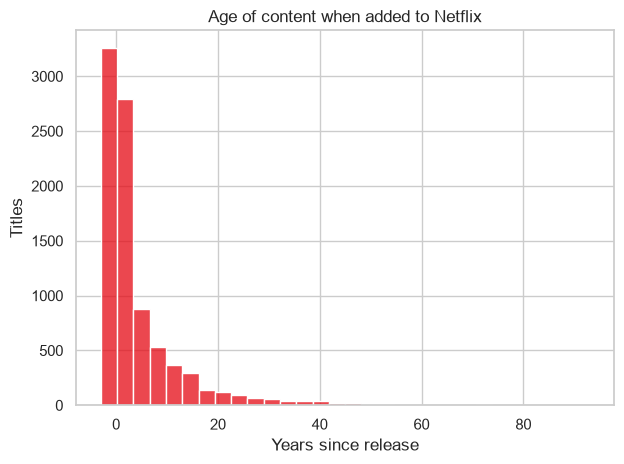

Content age: mean 4.7 years; median 1.0 years


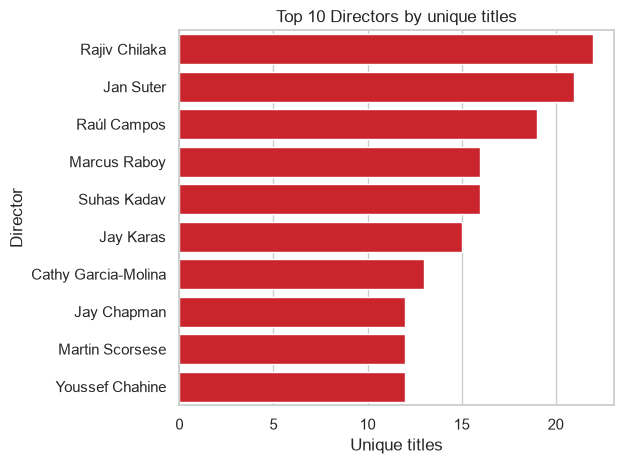

Top directors:
 director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Martin Scorsese        12
Youssef Chahine        12
Name: show_id, dtype: int64


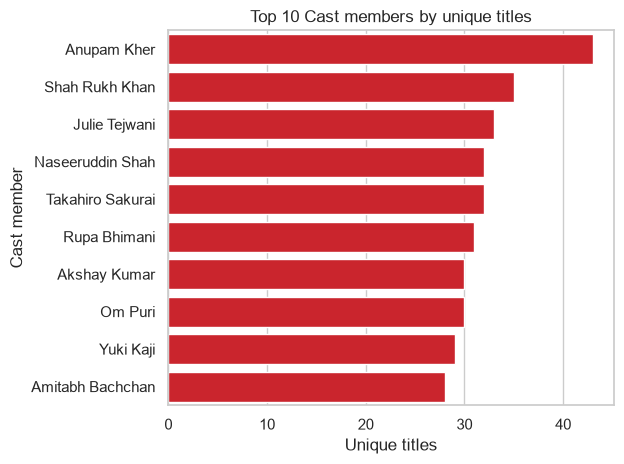

Top cast members:
 cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: show_id, dtype: int64


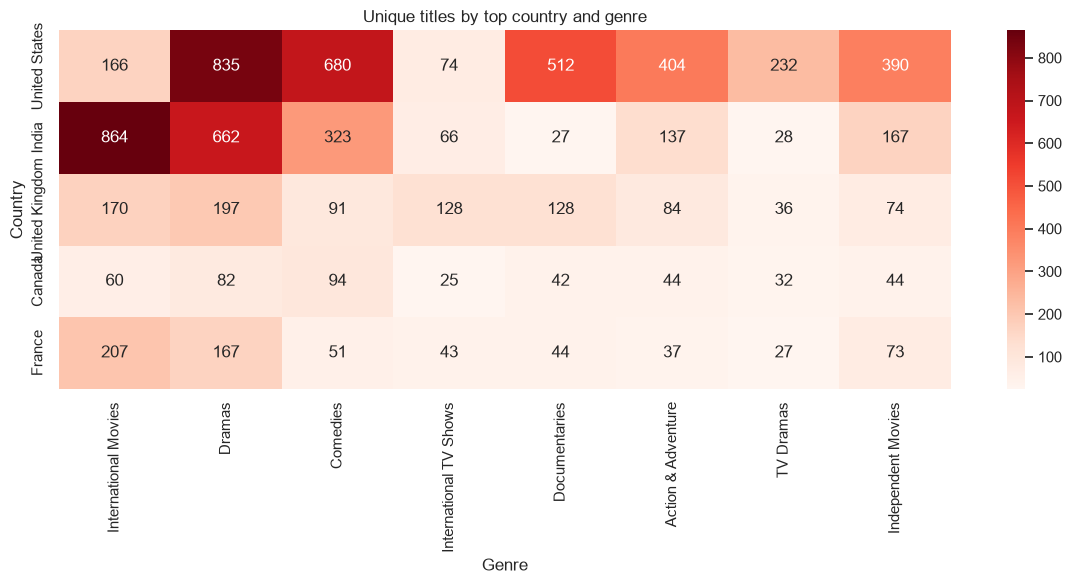

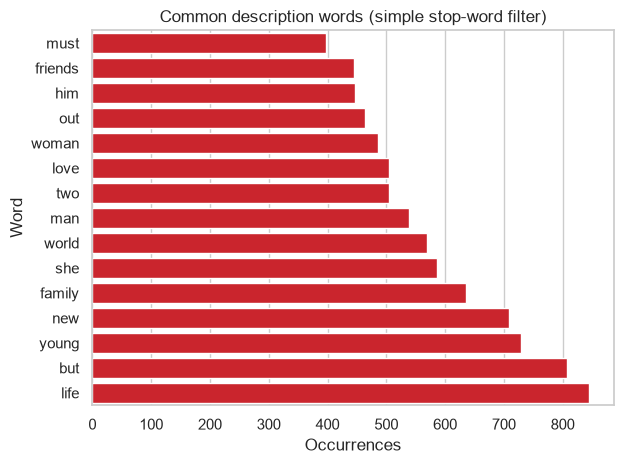

Common words:
 [('life', 845), ('but', 807), ('young', 729), ('new', 709), ('family', 635), ('she', 587), ('world', 570), ('man', 538), ('two', 505), ('love', 504), ('woman', 486), ('out', 464), ('him', 447), ('friends', 445), ('must', 398)]


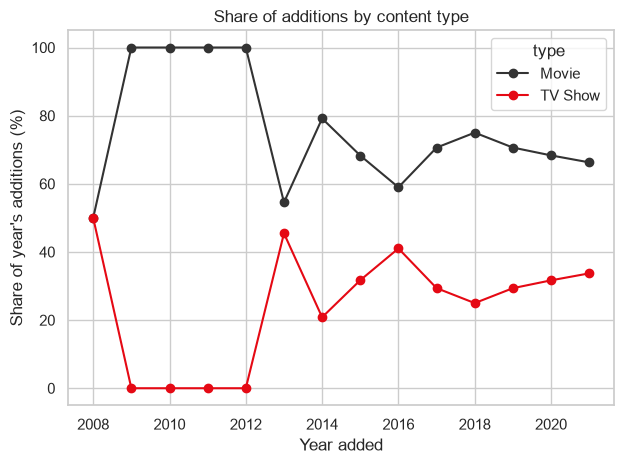

type,Movie,TV Show
year_added,,
2017,839,349
2018,1237,412
2019,1424,592
2020,1284,595
2021,993,505


In [3]:
IMG = ROOT / "images"
IMG.mkdir(exist_ok=True)
def save_chart(name):
    plt.tight_layout()
    plt.savefig(IMG / name, dpi=160, bbox_inches="tight")
    plt.show()

# 1. Movies versus TV Shows
type_counts = df["type"].value_counts()
type_pct = (type_counts / len(df) * 100).round(1)
ax = sns.barplot(x=type_counts.index, y=type_counts.values, color="#E50914")
ax.set(title="Netflix catalog by content type", xlabel="Type", ylabel="Titles")
for i, value in enumerate(type_counts.values): ax.text(i, value, f"{value:,} ({type_pct.iloc[i]}%)", ha="center", va="bottom")
save_chart("01_content_type.png")
print("Type totals and share (%):\n", pd.DataFrame({"count":type_counts,"percent":type_pct}))

# 2. Titles added by year
added_year = df.dropna(subset=["year_added"]).groupby("year_added")["show_id"].nunique()
ax = sns.lineplot(x=added_year.index.astype(int), y=added_year.values, marker="o", color="#E50914")
ax.set(title="Titles added to Netflix by year", xlabel="Year added", ylabel="Unique titles")
save_chart("02_additions_by_year.png")
print("Peak addition year:", int(added_year.idxmax()), "with", int(added_year.max()), "titles")

# 3. Month of addition
month_order = list(range(1,13)); month_counts = df.dropna(subset=["month_added"]).groupby("month_added")["show_id"].nunique().reindex(month_order, fill_value=0)
ax = sns.barplot(x=[pd.Timestamp(2000,m,1).strftime("%b") for m in month_order], y=month_counts.values, color="#E50914")
ax.set(title="Catalog additions by month", xlabel="Month added", ylabel="Unique titles")
save_chart("03_additions_by_month.png")
print("Most common month:", pd.Timestamp(2000,int(month_counts.idxmax()),1).strftime("%B"), int(month_counts.max()))

# 4. Countries, including India over time (distinct titles)
country_valid = by_country[by_country.country.ne("Unknown")]
top_countries = country_valid.groupby("country")["show_id"].nunique().nlargest(10)
ax = sns.barplot(y=top_countries.index, x=top_countries.values, color="#E50914")
ax.set(title="Top 10 countries by unique titles", xlabel="Unique titles", ylabel="Country")
save_chart("04_top_countries.png")
india = country_valid[country_valid.country.eq("India")].groupby("year_added")["show_id"].nunique().dropna()
if not india.empty:
    sns.lineplot(x=india.index.astype(int), y=india.values, marker="o", color="#E50914")
    plt.title("Indian titles added by year"); plt.xlabel("Year added"); plt.ylabel("Unique titles")
    save_chart("05_india_additions.png")
print("Top countries:\n", top_countries)

# 5. Genres overall and split by type
genre_valid = by_genre[by_genre.listed_in.ne("Unknown")]
top_genres = genre_valid.groupby("listed_in")["show_id"].nunique().nlargest(10)
ax = sns.barplot(y=top_genres.index, x=top_genres.values, color="#E50914")
ax.set(title="Top 10 genres", xlabel="Unique titles", ylabel="Genre")
save_chart("06_top_genres.png")
for content_type in ["Movie", "TV Show"]:
    counts = genre_valid[genre_valid.type.eq(content_type)].groupby("listed_in")["show_id"].nunique().nlargest(10)
    ax=sns.barplot(y=counts.index, x=counts.values, color="#E50914")
    ax.set(title=f"Top genres: {content_type}", xlabel="Unique titles", ylabel="Genre")
    save_chart("07_top_genres_" + content_type.lower().replace(" ", "_") + ".png")
print("Top genres:\n", top_genres)

# 6. Rating distribution and groups
rating_counts = df["rating"].fillna("Missing").value_counts().head(15)
sns.barplot(y=rating_counts.index, x=rating_counts.values, color="#E50914")
plt.title("Most common content ratings"); plt.xlabel("Titles"); plt.ylabel("Rating")
save_chart("08_rating_distribution.png")
group_counts = df["rating_group"].value_counts()
sns.barplot(x=group_counts.index, y=group_counts.values, color="#E50914")
plt.title("Content rating groups"); plt.xlabel("Group"); plt.ylabel("Titles")
save_chart("09_rating_groups.png")
adult_share = (df.rating_group.eq("Adults").mean()*100)
print("Adult-oriented titles:", f"{adult_share:.1f}%")

# 7. Movie minutes and TV seasons
movies=df[df.type.eq("Movie")].dropna(subset=["movie_minutes"])
sns.histplot(movies.movie_minutes.astype(int), bins=30, color="#E50914")
plt.title("Movie duration distribution"); plt.xlabel("Minutes"); plt.ylabel("Titles")
save_chart("10_movie_duration.png")
tv=df[df.type.eq("TV Show")].dropna(subset=["seasons"])
season_counts=tv.seasons.astype(int).value_counts().sort_index()
sns.barplot(x=season_counts.index, y=season_counts.values, color="#E50914")
plt.title("TV Shows by number of seasons"); plt.xlabel("Seasons"); plt.ylabel("Titles")
save_chart("11_tv_seasons.png")
print(f"Movie duration: mean {movies.movie_minutes.mean():.1f} min; median {movies.movie_minutes.median():.1f} min")
print("TV show season distribution:\n", season_counts)

# 8. Content age at addition
age=df.content_age.dropna().astype(int)
sns.histplot(age, bins=30, color="#E50914")
plt.title("Age of content when added to Netflix"); plt.xlabel("Years since release"); plt.ylabel("Titles")
save_chart("12_content_age.png")
print(f"Content age: mean {age.mean():.1f} years; median {age.median():.1f} years")

# 9. Directors and cast (exclude Unknown)
for table, col, label, filename in [(by_director,"director","Directors","13_top_directors.png"),(by_cast,"cast","Cast members","14_top_actors.png")]:
    top=table[table[col].ne("Unknown")].groupby(col)["show_id"].nunique().nlargest(10)
    sns.barplot(y=top.index, x=top.values, color="#E50914")
    plt.title(f"Top 10 {label} by unique titles"); plt.xlabel("Unique titles"); plt.ylabel(label[:-1])
    save_chart(filename)
    print(f"Top {label.lower()}:\n", top)

# 10. Genre-country heatmap, based on joined exploded dimensions
top5=top_countries.index[:5]; top8=top_genres.index[:8]
country_genre = country_valid[country_valid.country.isin(top5)][["show_id","country"]].drop_duplicates().merge(
    genre_valid[genre_valid.listed_in.isin(top8)][["show_id","listed_in"]].drop_duplicates(), on="show_id")
pivot=country_genre.groupby(["country","listed_in"])["show_id"].nunique().unstack(fill_value=0).reindex(index=top5,columns=top8,fill_value=0)
plt.figure(figsize=(12,6)); sns.heatmap(pivot, annot=True, fmt="d", cmap="Reds")
plt.title("Unique titles by top country and genre"); plt.xlabel("Genre"); plt.ylabel("Country")
save_chart("15_country_genre_heatmap.png")

# 11. Most common description words; standard library counts, no optional dependency
import re
from collections import Counter
stop_words=set("the a an and or of to in on for with from is are as at by this that their his her they it its into after when where who".split())
words=Counter(word for desc in df.description.dropna().str.lower() for word in re.findall(r"[a-z]{3,}",desc) if word not in stop_words)
common=pd.Series(dict(words.most_common(15))).sort_values()
sns.barplot(x=common.values, y=common.index, color="#E50914")
plt.title("Common description words (simple stop-word filter)"); plt.xlabel("Occurrences"); plt.ylabel("Word")
save_chart("16_description_words.png")
print("Common words:\n", words.most_common(15))

# 12. Additional supported comparison: type mix by addition year
mix=df.dropna(subset=["year_added"]).groupby(["year_added","type"])["show_id"].nunique().unstack(fill_value=0)
mix_pct=mix.div(mix.sum(axis=1),axis=0)*100
mix_pct.plot(kind="line", marker="o", color={"Movie":"#333333","TV Show":"#E50914"})
plt.title("Share of additions by content type"); plt.xlabel("Year added"); plt.ylabel("Share of year's additions (%)")
save_chart("17_type_mix_by_year.png")
display(mix.tail())

## 4. Findings and recommendations

The outputs below are computed from this file so findings stay tied to the exact dataset version. A catalog addition is not a view, completion, or preference signal.

In [4]:
# Compact, computed findings for review and use in the README.
print("Catalog size:", f"{len(df):,}")
print("Movie share:", f"{type_pct.get('Movie',0):.1f}%")
print("TV Show share:", f"{type_pct.get('TV Show',0):.1f}%")
print("Peak addition year:", int(added_year.idxmax()), f"({int(added_year.max()):,} titles)")
print("Peak month:", pd.Timestamp(2000,int(month_counts.idxmax()),1).strftime("%B"), f"({int(month_counts.max()):,} titles)")
print("Largest country dimension:", top_countries.index[0], f"({int(top_countries.iloc[0]):,} titles)")
print("Largest genre:", top_genres.index[0], f"({int(top_genres.iloc[0]):,} titles)")
print("Adult rating group share:", f"{adult_share:.1f}%")
print("Average / median movie runtime:", f"{movies.movie_minutes.mean():.1f} / {movies.movie_minutes.median():.1f} min")
print("Median content age:", f"{age.median():.1f} years")
print("\nRecommendations (catalog-level hypotheses, validate with audience data):")
print("1. Use country and genre coverage to identify underrepresented catalog combinations for further research.")
print("2. Compare movie and TV additions over time when planning a balanced acquisition pipeline.")
print("3. Check rating mix against intended audience segments before commissioning content.")
print("4. Pair this catalog with viewership, cost, and retention data before making investment decisions.")

Catalog size: 8,807
Movie share: 69.6%
TV Show share: 30.4%
Peak addition year: 2019 (2,016 titles)
Peak month: July (827 titles)
Largest country dimension: United States (3,690 titles)
Largest genre: International Movies (2,752 titles)
Adult rating group share: 45.5%
Average / median movie runtime: 99.6 / 98.0 min
Median content age: 1.0 years

Recommendations (catalog-level hypotheses, validate with audience data):
1. Use country and genre coverage to identify underrepresented catalog combinations for further research.
2. Compare movie and TV additions over time when planning a balanced acquisition pipeline.
3. Check rating mix against intended audience segments before commissioning content.
4. Pair this catalog with viewership, cost, and retention data before making investment decisions.


## Limitations

This is a historical snapshot with no viewing, revenue, licensing, or user engagement data. Country and genre tags can be multiple per title; exploded counts are title counts within each dimension and should not be added together. Ratings are classification labels, not quality scores. Addition dates may be missing or reflect source formatting. The year-based trends describe this file's recorded additions only.